<a href="https://colab.research.google.com/github/mixxr/gcolab-ml/blob/main/funnel/03_getting_real_data_chembl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Episode 3 — Getting Real Data (ChEMBL)
**Drug Discovery in Code** · [Life Sciences AI Applications]
To find real drugs we need real data: molecules that have actually been
tested against our target, and *how well they worked*. **ChEMBL** is the public database that has it —
millions of measured activities. We'll pull the known **EGFR** inhibitors and their potencies into a
pandas table, then convert potency into the scale everyone uses: **pIC50**.
> Educational only — not medical advice.

## Setup
`pip install chembl_webresource_client` (already in the repo env).

In [ ]:
pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
from chembl_webresource_client.new_client import new_client
import pandas as pd, numpy as np

/usr/local/lib/python3.13/dist-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


## 1. Find the target
Our target is **EGFR** — the epidermal growth factor receptor, ChEMBL id **CHEMBL203**.

In [ ]:
target = new_client.target
list(target.filter(target_chembl_id="CHEMBL203")
            .only(["pref_name", "organism"]))

[{'organism': 'Homo sapiens', 'pref_name': 'Epidermal growth factor receptor'}]

## 2. Pull the measured activities
We ask for **IC50** values in **nM** with an exact (`=`) relation — the cleanest, most comparable
measurements. (EGFR has thousands; we cap at 1500 for a quick run — delete the cap to pull them all.)

In [ ]:

acts = new_client.activity.filter(
    target_chembl_id="CHEMBL203",
    standard_type="IC50",
    standard_relation="=",
    standard_units="nM",
).only(["molecule_chembl_id", "canonical_smiles", "standard_value","standard_units"])
print("Existing #acts:", len(acts))
# rows = []
# for a in acts:
#     if a["standard_value"] and a["canonical_smiles"]:
#         rows.append((a["molecule_chembl_id"],
#                      a["canonical_smiles"],
#                      float(a["standard_value"])))
#     if len(rows) >= 1500:   # cap for speed; remove to pull all
#         break
from tqdm import tqdm
MAX_RECS = 1000 # it is used to spped up the tests. Change/remove it when ready
records = list(tqdm(acts[:MAX_RECS], desc="Downloading ChEMBL records..."))
df = pd.DataFrame.from_dict(records)
print("Downloaded #acts:", len(records))
df.head(3)

Existing #acts: 19646


Downloaded #acts: 1000


,canonical_smiles,molecule_chembl_id,standard_units,standard_value,units,value
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,41.0,uM,0.041
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,300.0,uM,0.3
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,7820.0,uM,7.82


In [ ]:
df["standard_units"].unique()

array(['nM'], dtype=object)

In [ ]:
#df = pd.DataFrame(rows, columns=["molecule_chembl_id", "smiles", "IC50_nM"])
# rename columns for clearity only
df = df.rename(columns={
    "canonical_smiles": "smiles",
    "standard_value": "IC50_nM"
})
# The ChEMBL client returns these values as strings (like "250.0"), so they need converting before you can compute pIC50.
# df.IC50_nM = df.IC50_nM.astype(float)
# errors="coerce" turns anything that can't be parsed into NaN instead of raising an error.
df.IC50_nM = pd.to_numeric(df.IC50_nM, errors="coerce")

# remove NaN values
df = df [df.IC50_nM.notna()]
print("Resulting #records:", len(df))
df.head(3)

Resulting #records: 1000


,smiles,molecule_chembl_id,standard_units,IC50_nM,units,value
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,41.0,uM,0.041
1,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,300.0,uM,0.3
2,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,CHEMBL68920,nM,7820.0,uM,7.82


In [ ]:
# check if there are values to cap
df = df[df.IC50_nM <= 10**8]
print("Resulting #records:", len(df))

Resulting #records: 777


## 3. Clean up, and convert IC50 → pIC50
A molecule can be measured many times, so we take the **median** per molecule. Then we convert
IC50 (in nM) to **pIC50** = 9 − log₁₀(IC50). Higher pIC50 = more potent; pIC50 of 6 means 1 µM,
9 means 1 nM. It's the scale every model in later episodes will predict.

In [ ]:
df = (df[df.IC50_nM > 0]
        .groupby(["molecule_chembl_id", "smiles"], as_index=False)
        .IC50_nM.median())

df["pIC50"] = 9 - np.log10(df.IC50_nM)
df = df.sort_values("pIC50", ascending=False).reset_index(drop=True)

print(len(df), "unique EGFR inhibitors")
df.head()[["molecule_chembl_id", "IC50_nM", "pIC50"]].round(2)

777 unique EGFR inhibitors


,molecule_chembl_id,IC50_nM,pIC50
0,CHEMBL35820,0.01,11.22
1,CHEMBL53753,0.01,11.10
2,CHEMBL66031,0.01,11.10
3,CHEMBL420624,0.10,10.00
4,CHEMBL127041,0.24,9.62


## 4. Look at the potency distribution

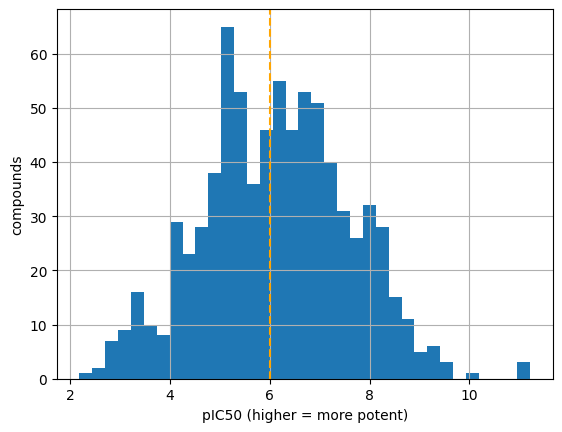

In [ ]:
# It splits the range of potency values into 35 equal-width intervals ("bins") and shows how many compounds fall into each.
df.pIC50.hist(bins=35)
import matplotlib.pyplot as plt
plt.axvline(6, color="orange", ls="--")   # 1 µM — a common activity cutoff
plt.xlabel("pIC50 (higher = more potent)"); plt.ylabel("compounds");
plt.savefig("03_hist_distribution.pdf")



In [ ]:
# save it — we'll reuse this dataset in every remaining episode
df.to_csv("03_egfr_chembl.csv", index=False)

Just over a thousand real, measured EGFR inhibitors — from single-digit nanomolar blockbusters to
weak micromolar hits. **This dataset is the backbone of the rest of the series.**

## Recap
- **ChEMBL** gives you real molecules *and* how potent they were, for a target.
- We pulled EGFR IC50 data and tidied it into a pandas table.
- **pIC50** puts potency on a clean log scale — the label our models will predict.

**Next — Episode 4:** put these molecules through **drug-likeness filters** (Lipinski + structural
alerts) to trim the set down to the ones worth pursuing.